/Users/jjiang10/Data/AdrenalDiff/processed_data/models_output_augmented/Group5_Fold*_xgboost_shap_values.csv
Mean pairwise Spearman(rank) across folds: 0.818
Mean pairwise Kendall tau(rank) across folds: 0.650
/Users/jjiang10/Data/AdrenalDiff/processed_data/models_output_augmented/Group7_Fold*_xgboost_shap_values.csv
Mean pairwise Spearman(rank) across folds: 0.851
Mean pairwise Kendall tau(rank) across folds: 0.690


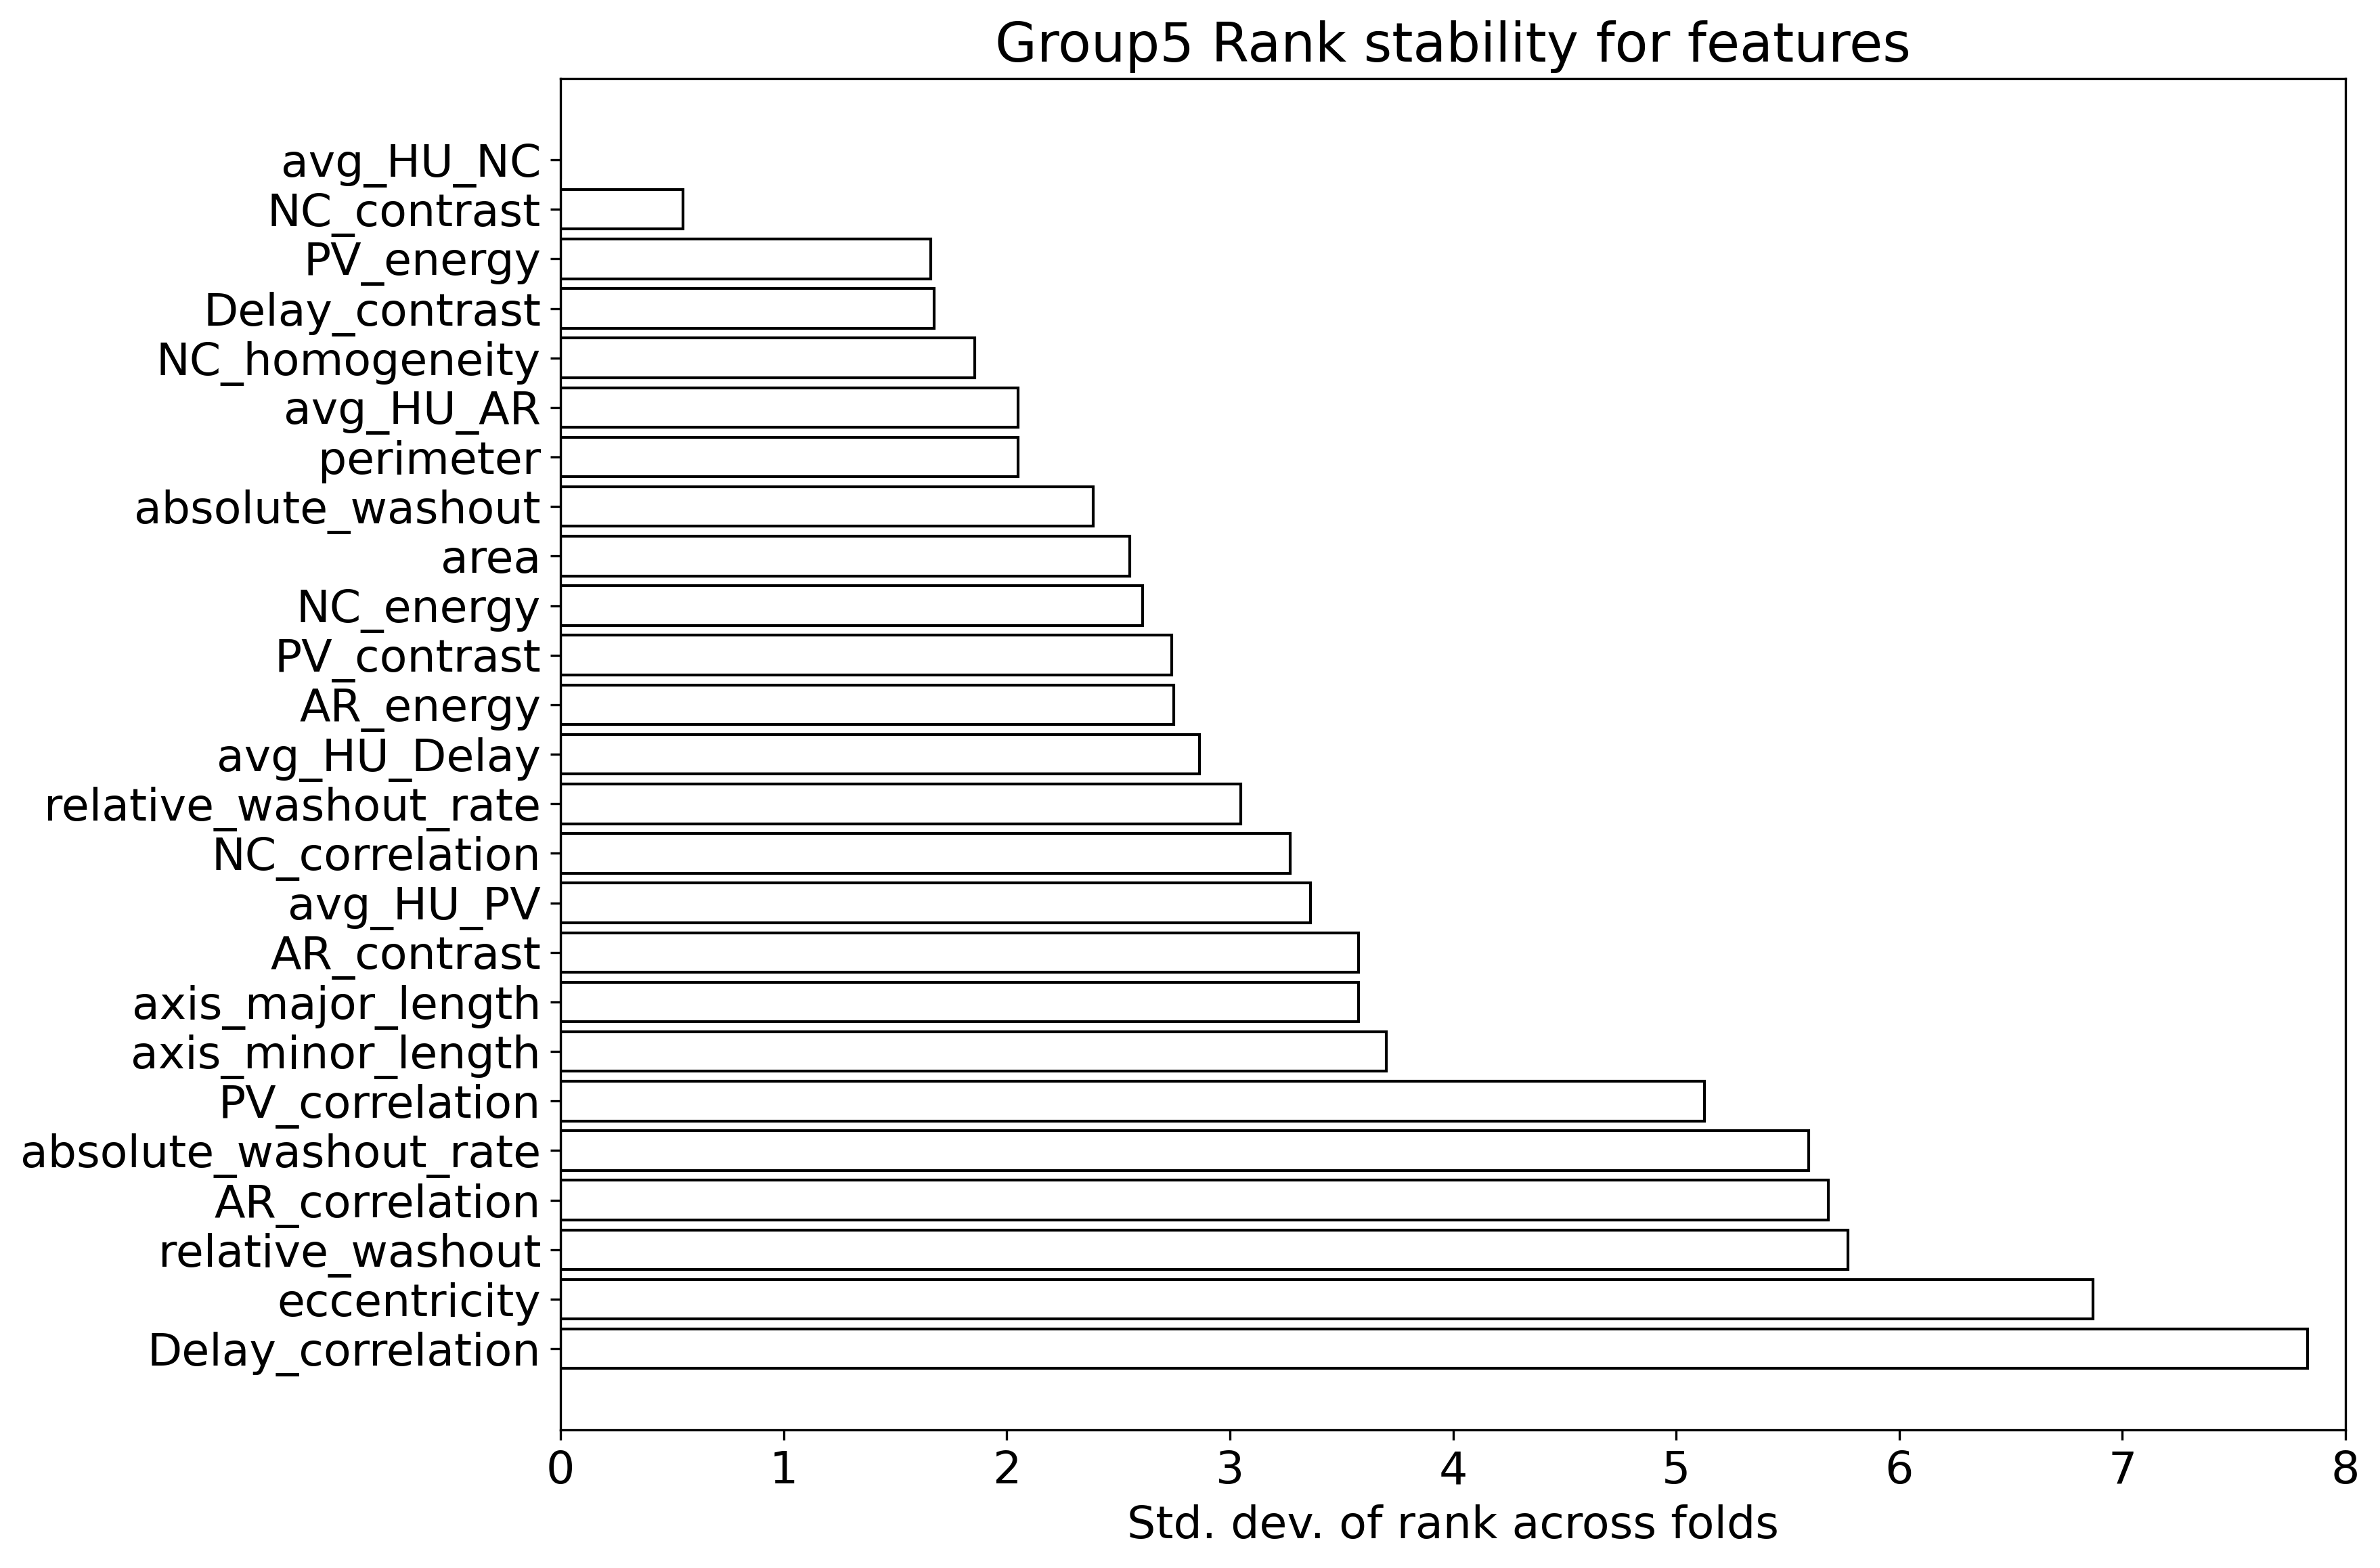

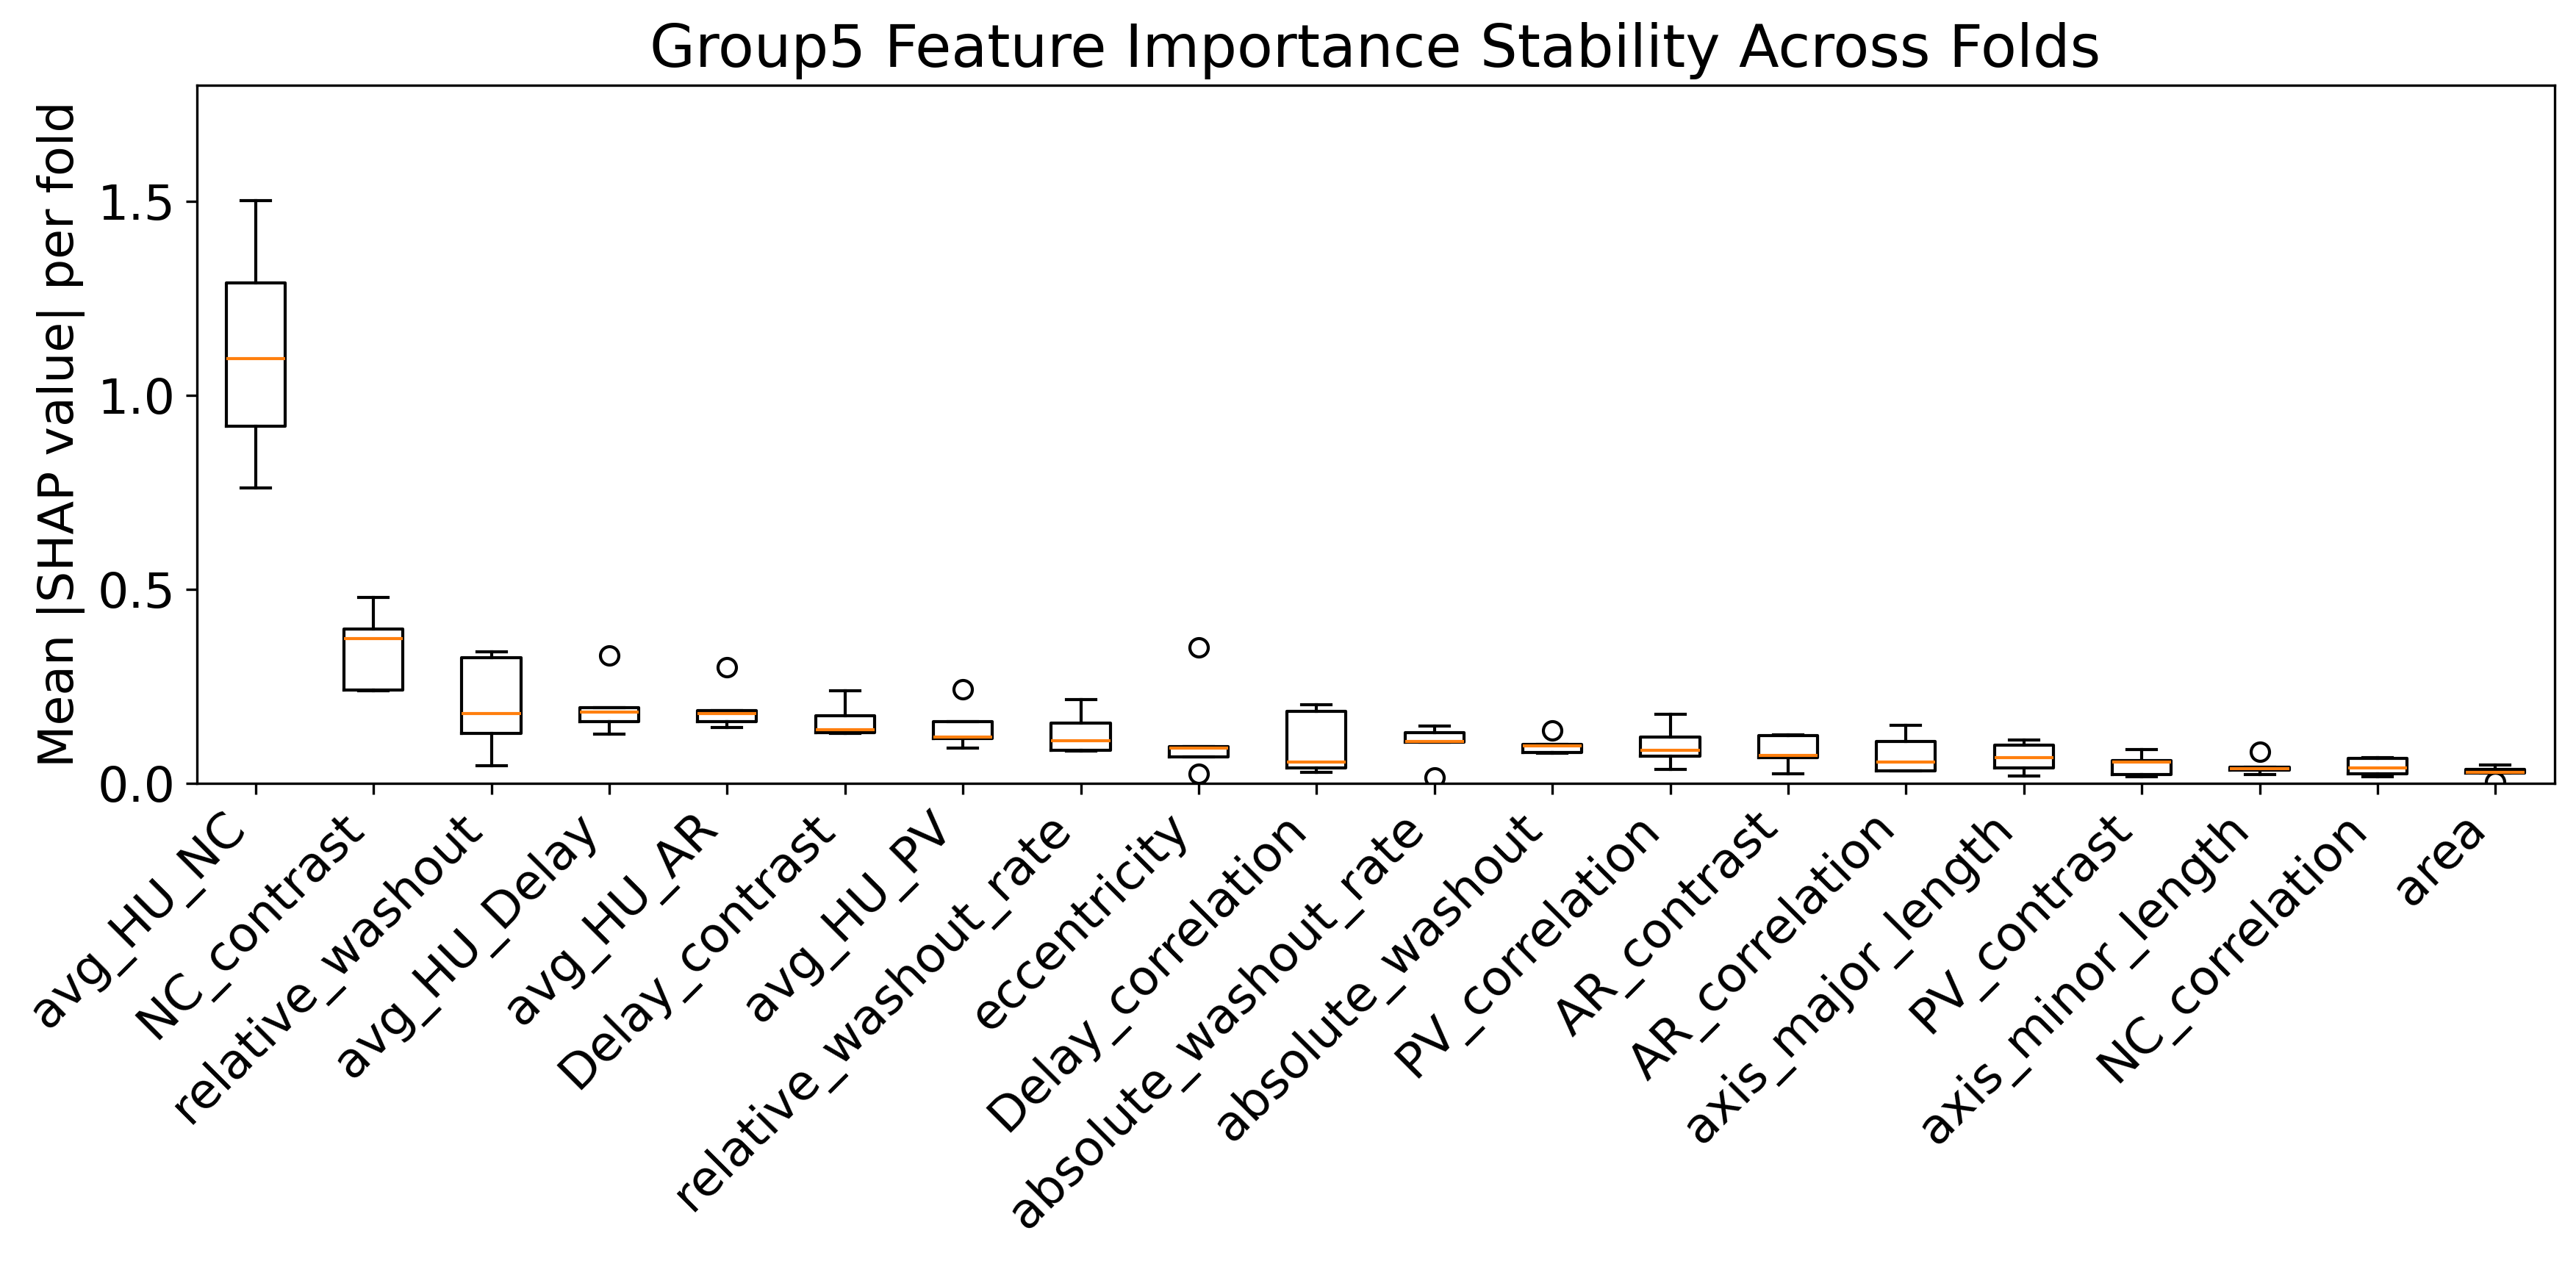

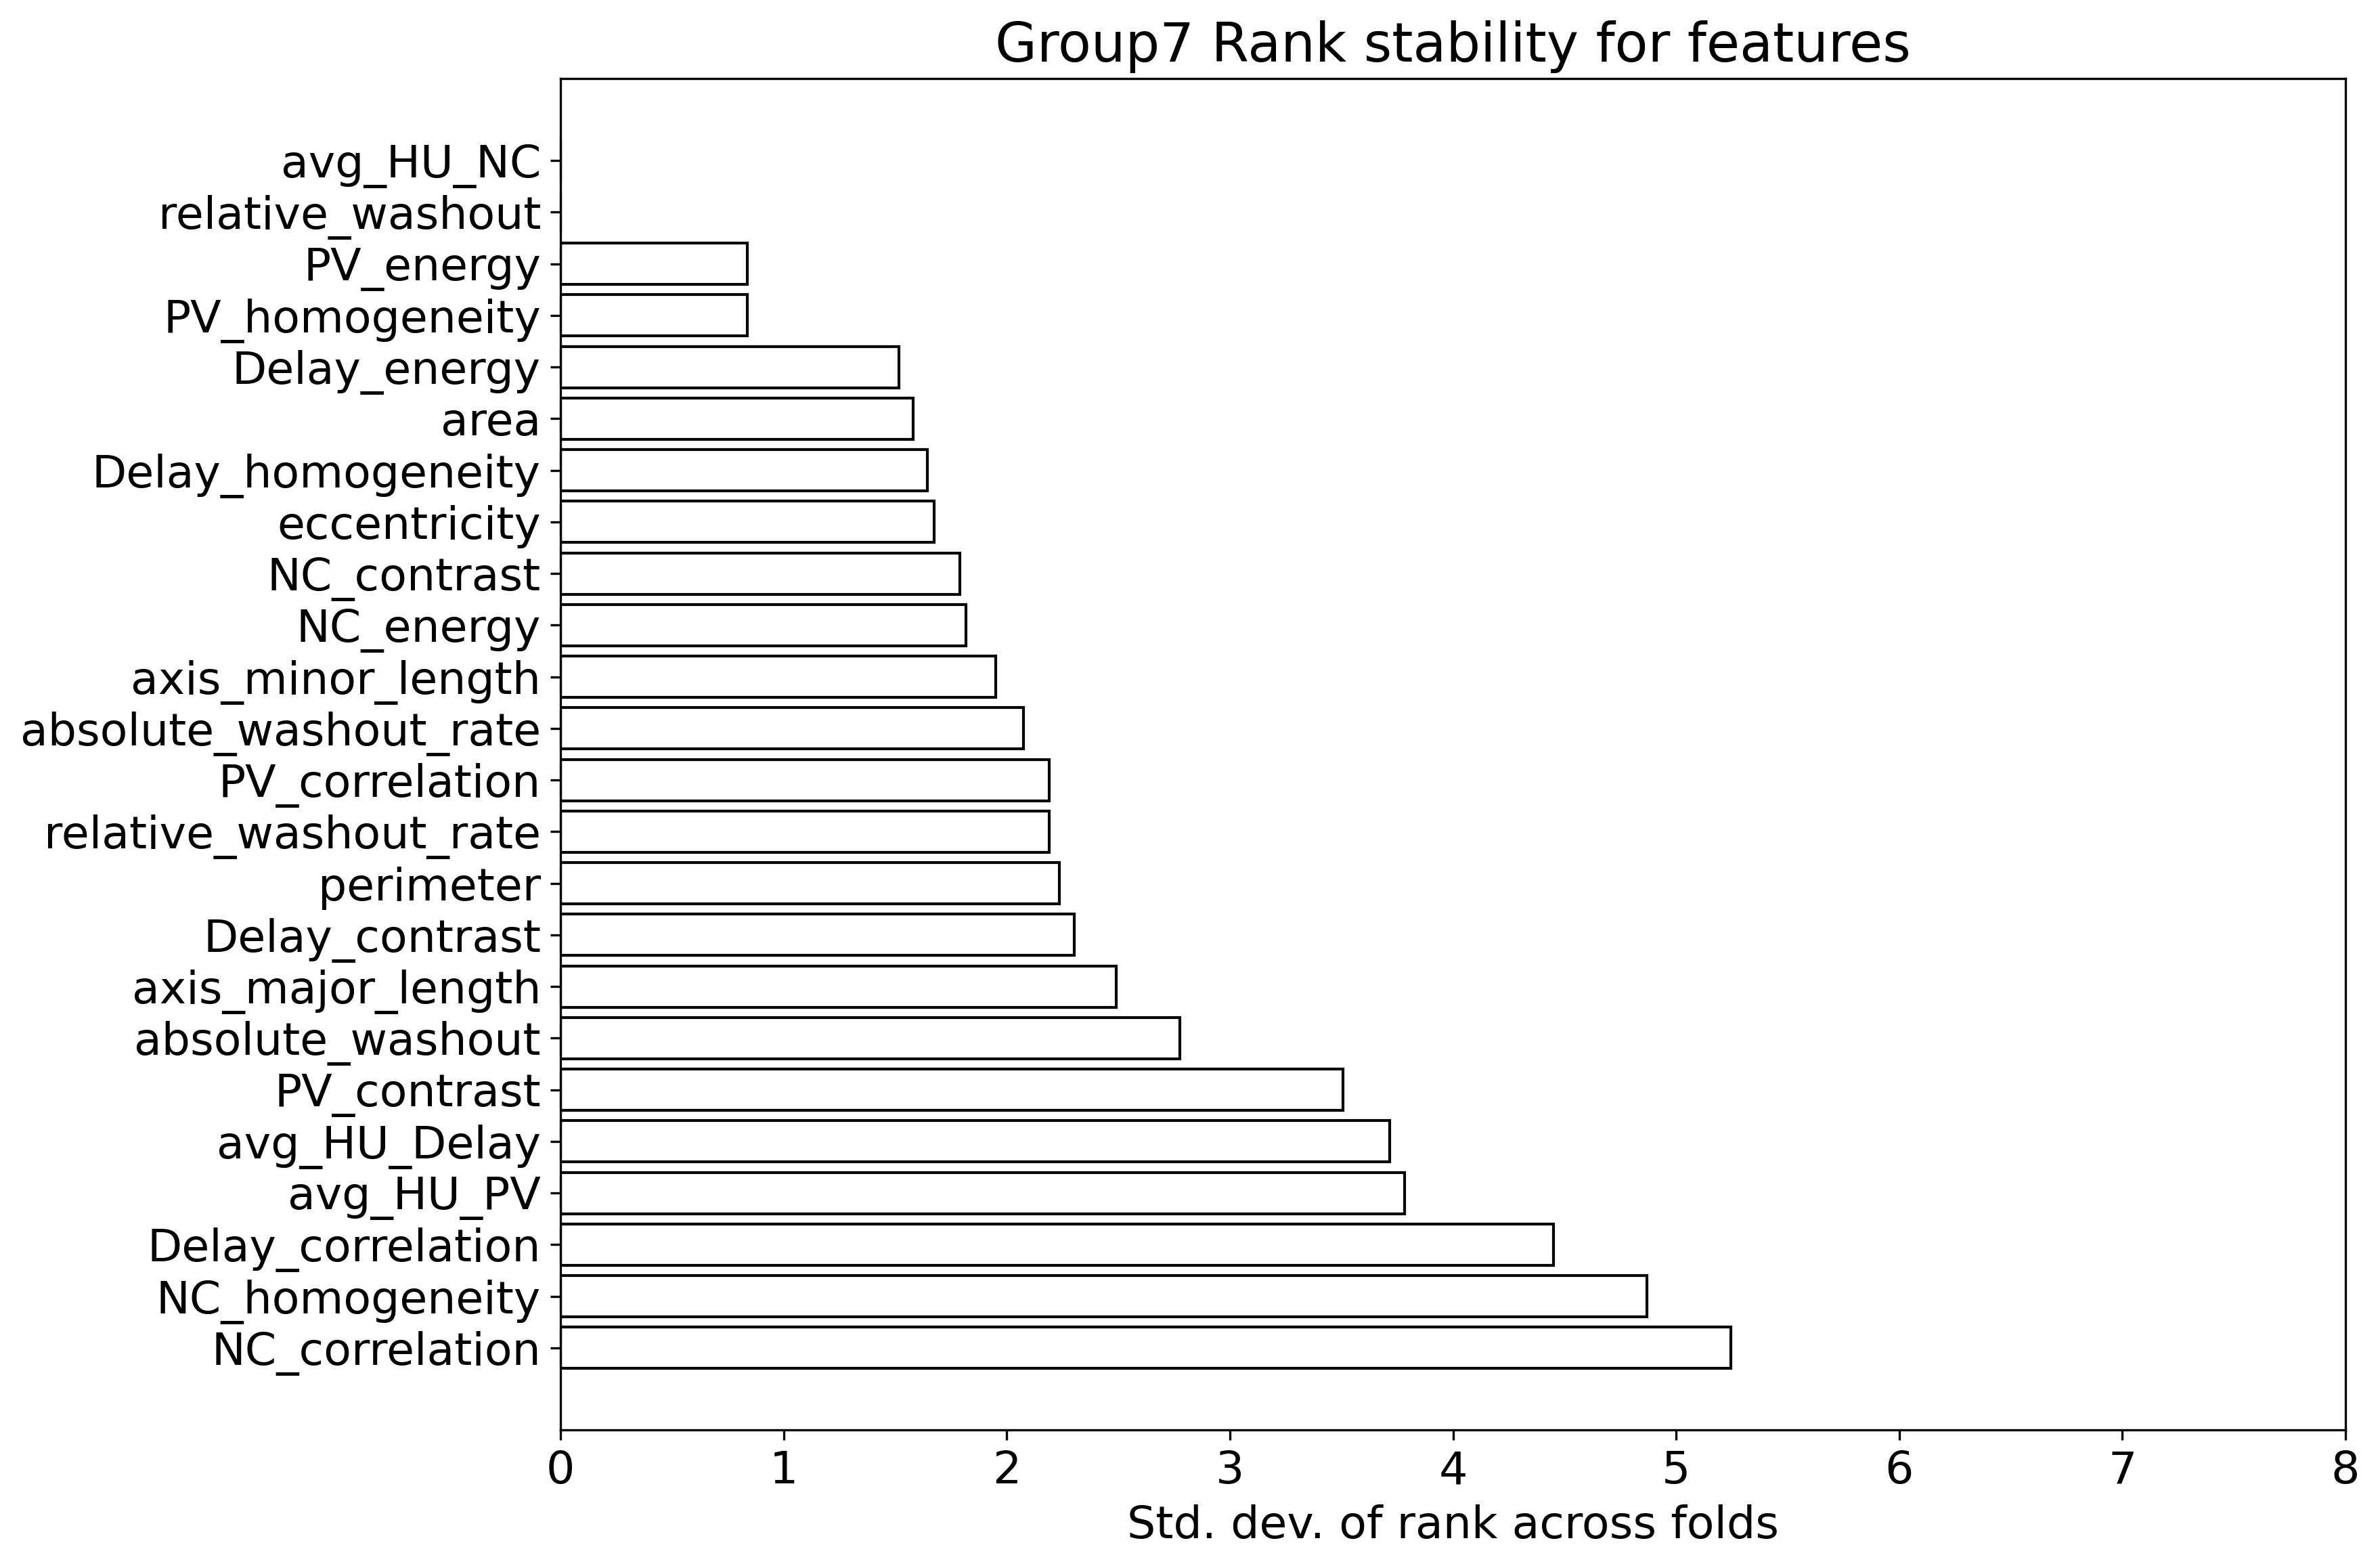

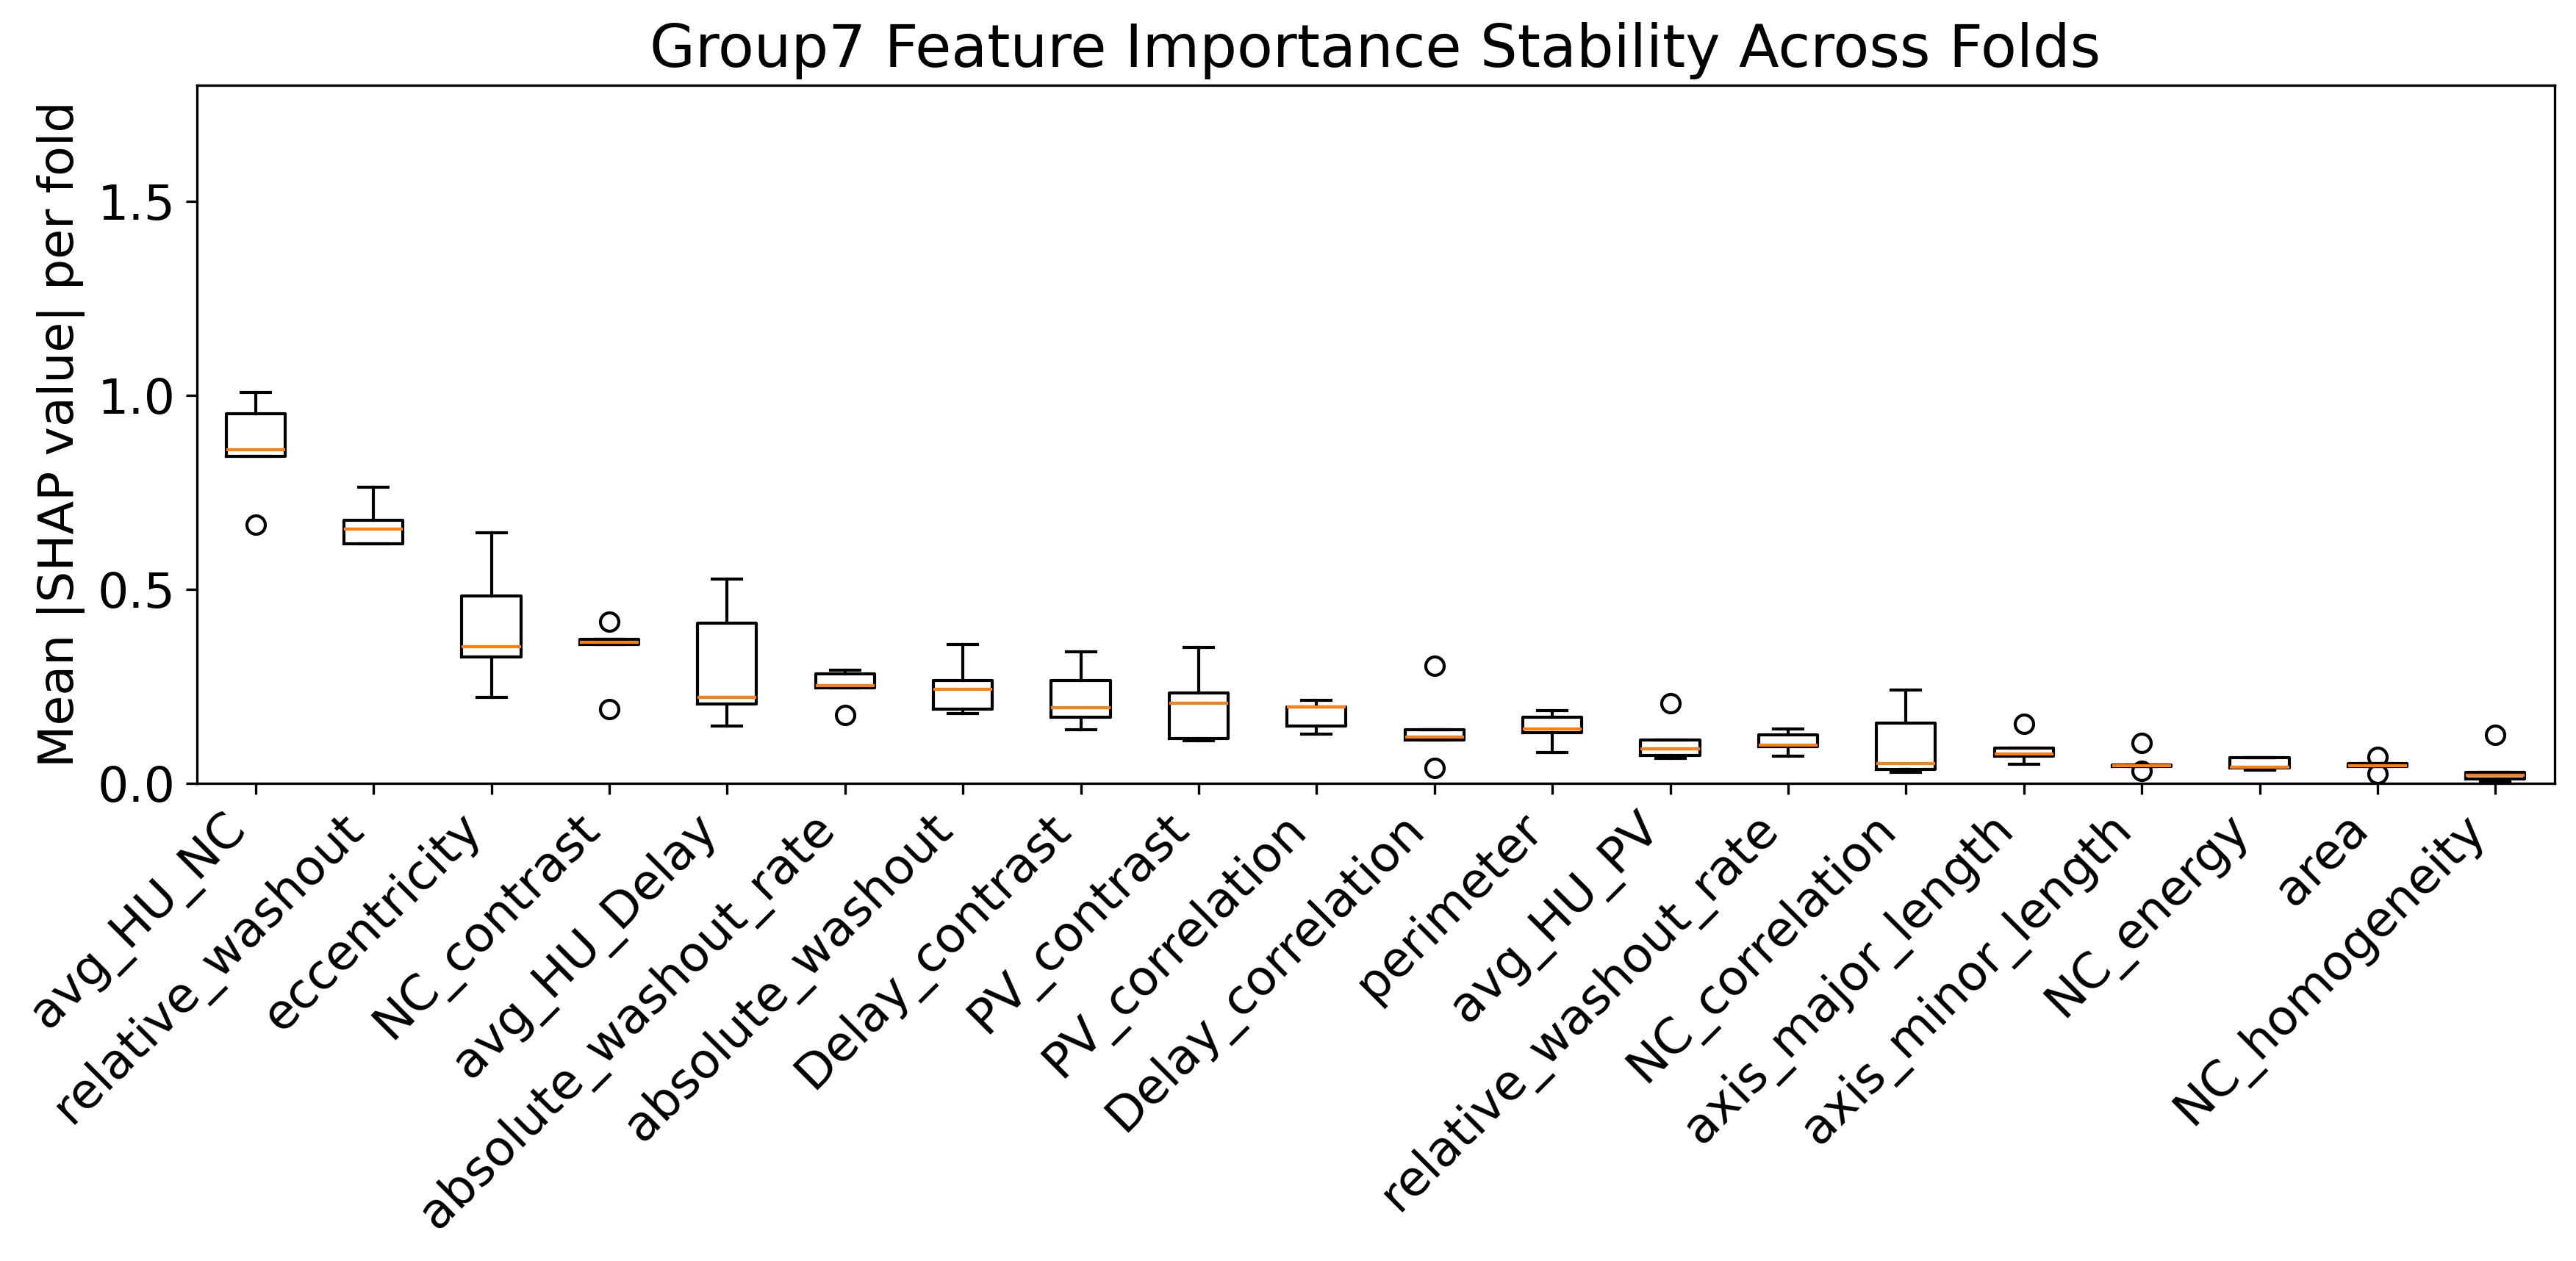

In [ ]:

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Helpers
# -----------------------------
def spearman_corr(a: np.ndarray, b: np.ndarray) -> float:
    """Spearman correlation via Pearson correlation of ranks."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a = a - a.mean()
    b = b - b.mean()
    denom = (np.sqrt((a*a).sum()) * np.sqrt((b*b).sum()))
    return float((a*b).sum() / denom) if denom > 0 else np.nan

def kendall_tau(a: np.ndarray, b: np.ndarray) -> float:
    """
    Kendall tau-a (no tie correction). Works fine if ranks are mostly unique.
    If many ties exist, consider scipy.stats.kendalltau.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n = len(a)
    conc = disc = 0
    for i in range(n):
        for j in range(i + 1, n):
            da = a[i] - a[j]
            db = b[i] - b[j]
            prod = da * db
            if prod > 0:
                conc += 1
            elif prod < 0:
                disc += 1
    denom = n * (n - 1) / 2
    return (conc - disc) / denom if denom > 0 else np.nan

def compute_fold_importance(csv_path: str, label_col="True_Label") -> pd.Series:
    """Return Series: feature -> mean(abs(shap)) for one fold."""
    df = pd.read_csv(csv_path)
    feat_cols = [c for c in df.columns if c != label_col]
    imp = df[feat_cols].abs().mean(axis=0)
    imp.name = os.path.basename(csv_path)
    return imp

# -----------------------------
# Main: load all folds and compute ranks
# -----------------------------
# Point this to your SHAP files
# Example pattern: ".../Group1_Fold*_XGBoost_shap_values.csv"

if __name__ == "__main__":
    from config import DATA_ROOT_DIR
    DATA_type = "augmented"  # or "original"
    # DATA_type = "original"  # or "augmented"
    if DATA_type == "original":
        data_dir = os.path.join(DATA_ROOT_DIR, "processed_data/models_output")
        output_dir = os.path.join(DATA_ROOT_DIR, "processed_data/models_output_figures")
    elif DATA_type == "augmented":
        data_dir = os.path.join(DATA_ROOT_DIR, "processed_data/models_output_augmented")
        output_dir = os.path.join(DATA_ROOT_DIR, "processed_data/models_output_augmented_figures")
    else:
        raise ValueError(f"Unknown DATA_type: {DATA_type}")

    
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Groups = [f"Group{i}" for i in range(1, 16)]  
    Groups = ["Group5", "Group7"] 
    for group in Groups:
        pattern = os.path.join(data_dir, f"{group}_Fold*_xgboost_shap_values.csv")
        print(pattern)
        csv_files = sorted(glob.glob(pattern))
        if len(csv_files) < 2:
            continue  # Need at least 2 folds to assess consistency
        # Importance matrix: rows=fold files, cols=features
        imp_list = [compute_fold_importance(p) for p in csv_files]
        imp_df = pd.DataFrame(imp_list).fillna(0.0)  # (n_folds x n_features)

        # Convert to ranks per fold (1 = most important)
        # method='average' handles ties; smaller rank = more important
        rank_df = imp_df.rank(axis=1, ascending=False, method="average")

        # -----------------------------
        # Consistency metrics
        # -----------------------------
        fold_names = list(rank_df.index)
        n_folds = len(fold_names)

        spearman_mat = np.full((n_folds, n_folds), np.nan, dtype=float)
        kendall_mat  = np.full((n_folds, n_folds), np.nan, dtype=float)

        for i in range(n_folds):
            for j in range(n_folds):
                r_i = rank_df.iloc[i].values
                r_j = rank_df.iloc[j].values
                spearman_mat[i, j] = spearman_corr(r_i, r_j)
                kendall_mat[i, j]  = kendall_tau(r_i, r_j)

        # Summary consistency numbers
        upper = np.triu_indices(n_folds, k=1)
        mean_spearman = np.nanmean(spearman_mat[upper])
        mean_kendall  = np.nanmean(kendall_mat[upper])

        print(f"Mean pairwise Spearman(rank) across folds: {mean_spearman:.3f}")
        print(f"Mean pairwise Kendall tau(rank) across folds: {mean_kendall:.3f}")

        # -----------------------------
        # Figure 1: heatmap of rank correlations (Spearman)
        # -----------------------------
        # plt.figure(figsize=(8, 6), dpi=300)
        # plt.rcParams.update({'font.size': 14})  
        # im = plt.imshow(spearman_mat, vmin=-1, vmax=1, aspect="auto")
        # plt.colorbar(im, label="Spearman correlation (ranks)")
        # plt.xticks(range(n_folds), [f"Fold{i}" for i in range(n_folds)], rotation=45, ha="right")
        # plt.yticks(range(n_folds), [f"Fold{i}" for i in range(n_folds)])
        # plt.title(f"Rank-order consistency across folds\nMean Spearman={mean_spearman:.3f}")
        # plt.tight_layout()
        # save_path = os.path.join(output_dir, f"{group}_rank_consistency_heatmap.png")
        # plt.savefig(save_path, dpi=300)
        # plt.show()

        # -----------------------------
        # Figure 2: rank variability for top-N features (by mean importance)
        # -----------------------------
        top_n = 25
        mean_imp = imp_df.mean(axis=0).sort_values(ascending=False)
        top_features = mean_imp.index[:top_n]

        rank_std = rank_df[top_features].std(axis=0).sort_values(ascending=True)  # smaller std => more stable
        plt.figure(figsize=(12, 8), dpi=300)
        plt.rcParams.update({'font.size': 16})
        plt.barh(rank_std.index[::-1], rank_std.values[::-1], edgecolor='black', facecolor='None')
        plt.xlabel("Std. dev. of rank across folds") # (lower = more consistent)
        plt.xlim(0, 8)
        plt.title(f"{group} Rank stability for features")
        plt.tight_layout()
        save_path = os.path.join(output_dir, f"{group}_rank_stability.png")
        plt.savefig(save_path, dpi=300)
        # plt.show()

        # -----------------------------
        # Optional Figure 3: bump chart (rank trajectories) for top-N features
        # -----------------------------
        # plt.figure()
        # x = np.arange(n_folds)
        # for f in top_features:
        #     y = rank_df[f].values  # rank per fold
        #     plt.plot(x, y, marker="o", linewidth=1)
        # plt.gca().invert_yaxis()  # rank 1 at top
        # plt.xticks(x, [f"Fold{i}" for i in range(n_folds)], rotation=45, ha="right")
        # plt.ylabel("Rank (1 = most important)")
        # plt.title(f"Rank trajectories across folds")
        # plt.tight_layout()
        # save_path = os.path.join(output_dir, f"{group}_rank_trajectories.png")
        # plt.savefig(save_path, dpi=300)
        # plt.show()


        # -------------------------------------------------
        # 2. Compute mean(|SHAP|) per feature per fold
        # -------------------------------------------------
        importance_list = []

        for file in csv_files:
            df = pd.read_csv(file)
            feature_cols = [c for c in df.columns if c != "True_Label"]
            
            fold_importance = df[feature_cols].abs().mean(axis=0)
            importance_list.append(fold_importance)

        # rows = folds, columns = features
        importance_df = pd.DataFrame(importance_list)

        # -------------------------------------------------
        # 3. Order features by average importance
        # -------------------------------------------------
        mean_importance = importance_df.mean(axis=0)
        ordered_features = mean_importance.sort_values(ascending=False).index

        importance_df = importance_df[ordered_features]

        # Optional: show only top N features
        top_n = 20
        importance_df = importance_df.iloc[:, :top_n]

        # -------------------------------------------------
        # 4. Create boxplot
        # -------------------------------------------------
        plt.figure(figsize=(12, 6), dpi=300)
        plt.rcParams.update({'font.size': 16})  
        plt.boxplot(
            importance_df.values,
            vert=True,
            patch_artist=False
        )

        plt.xticks(
            ticks=np.arange(1, importance_df.shape[1] + 1),
            labels=importance_df.columns,
            rotation=45,
            ha="right"
        )
        plt.ylabel(f"Mean |SHAP value| per fold")
        plt.ylim(0, 1.8)
        plt.title(f"{group} Feature Importance Stability Across Folds") # \n(Ordered by Average Importance)
        plt.tight_layout()
        save_path = os.path.join(output_dir, f"{group}_feature_importance_boxplot.png")
        plt.savefig(save_path, dpi=300)
        # plt.show()


